In [1]:
from music21 import *
import copy

/Users/skye/.cache/uv/archive-v0/0woMiqm0BCKIsVKkpcGVe/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
score = converter.parse('./assets/flight-of-the-bumblebee-for-b-clarinet.mxl')
score.metadata.composer = "Nikolai Rimsky-Korsakov"
score.metadata.movementName = "Flight of the Bumblebee"

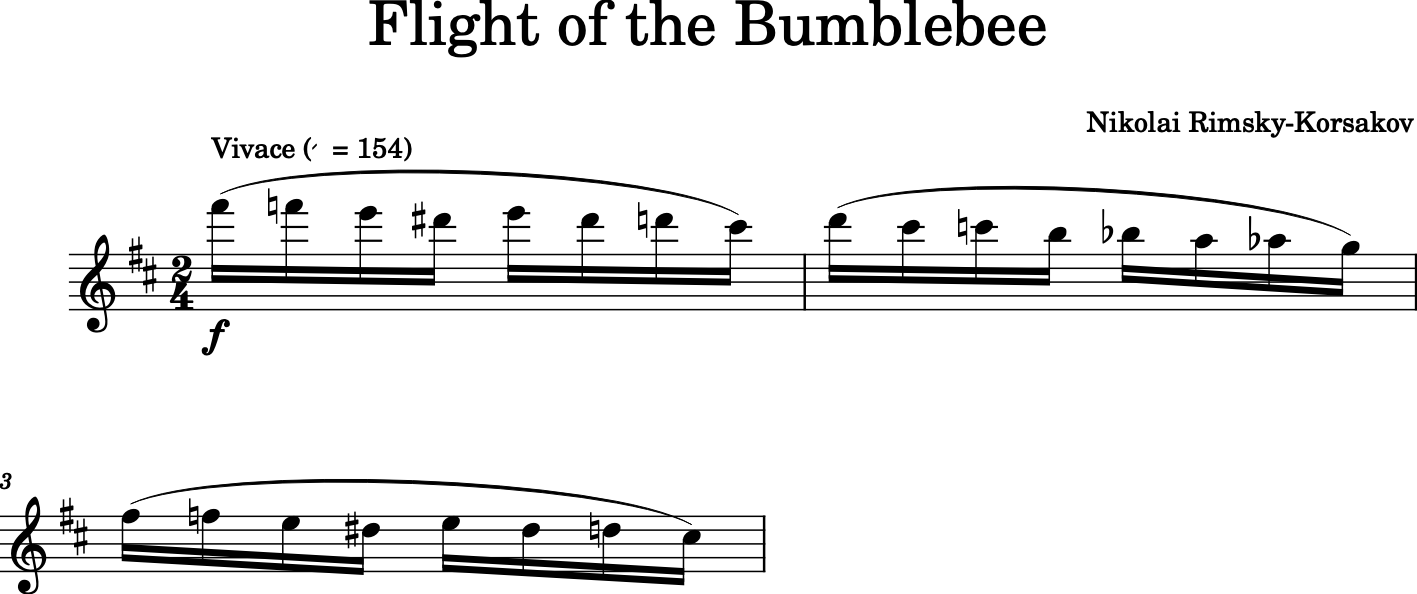

In [3]:
# Show the first three bars
score.measures(1,3).show()

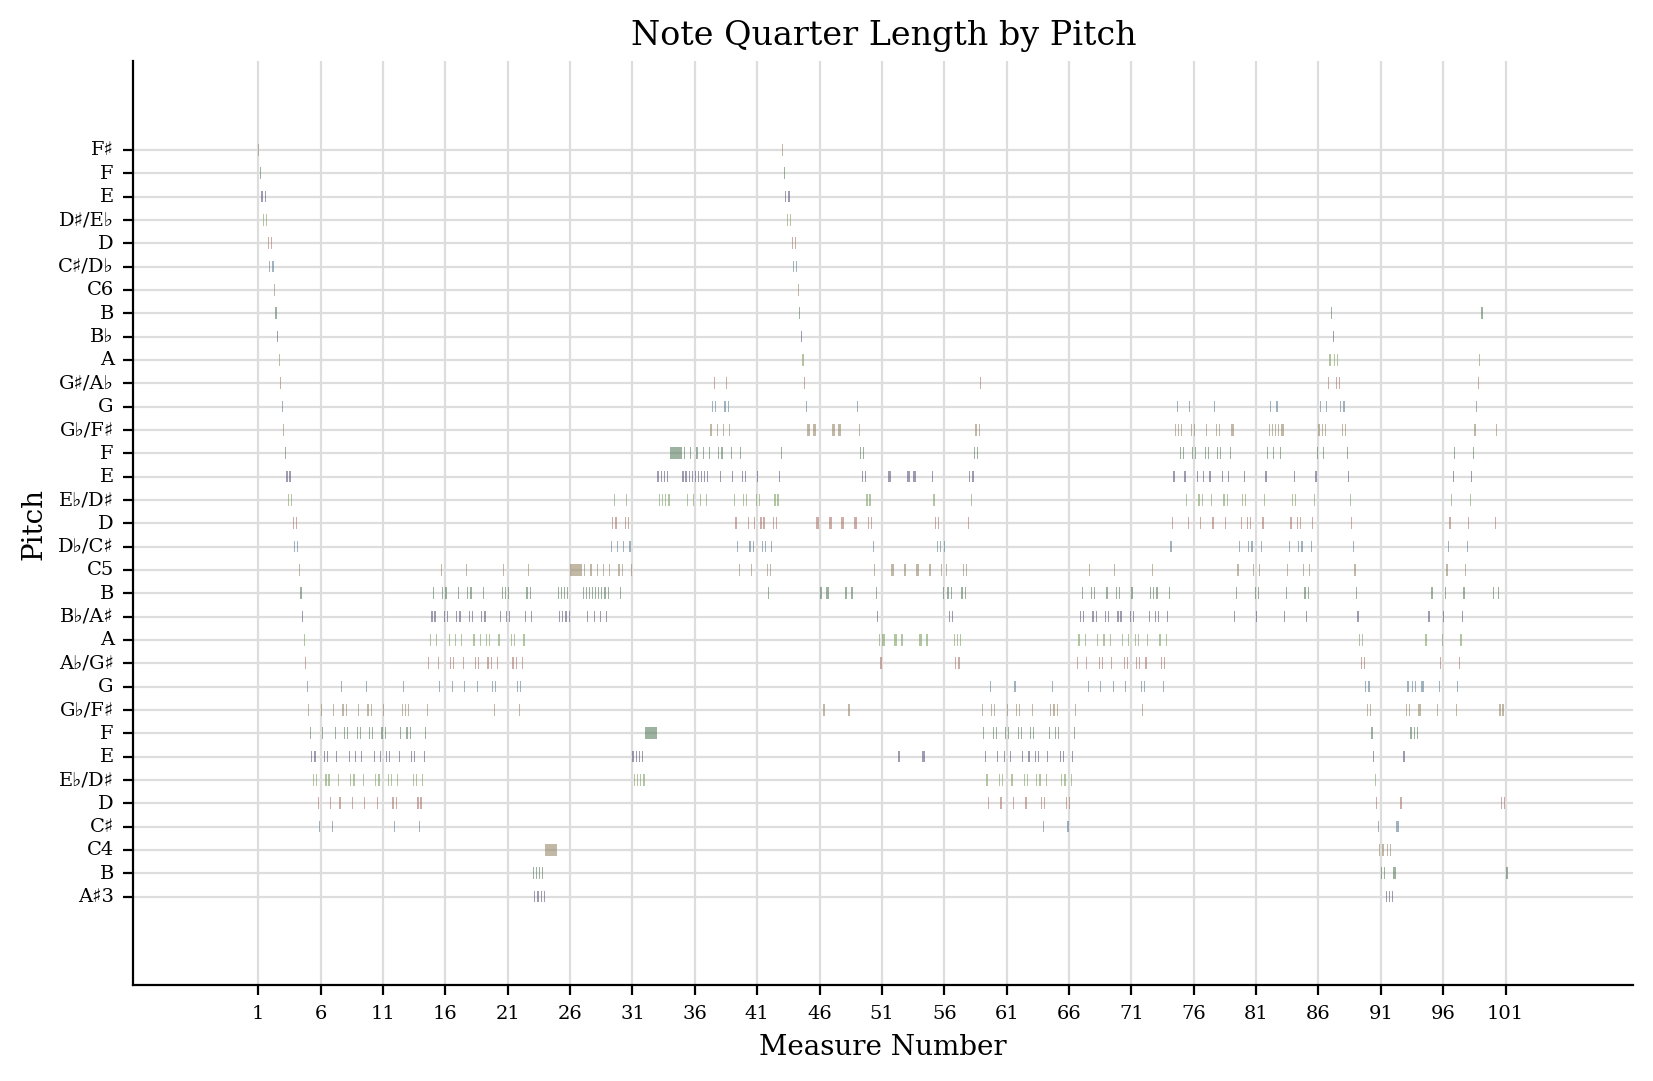

In [4]:
# From looking at the pianoroll, we can see that the bee is going ALLL over the place. 
# Not very streamlined. Lots of extra energy being spent.
score.plot('pianoroll')

In [5]:
score.measures(1,10).show('midi')

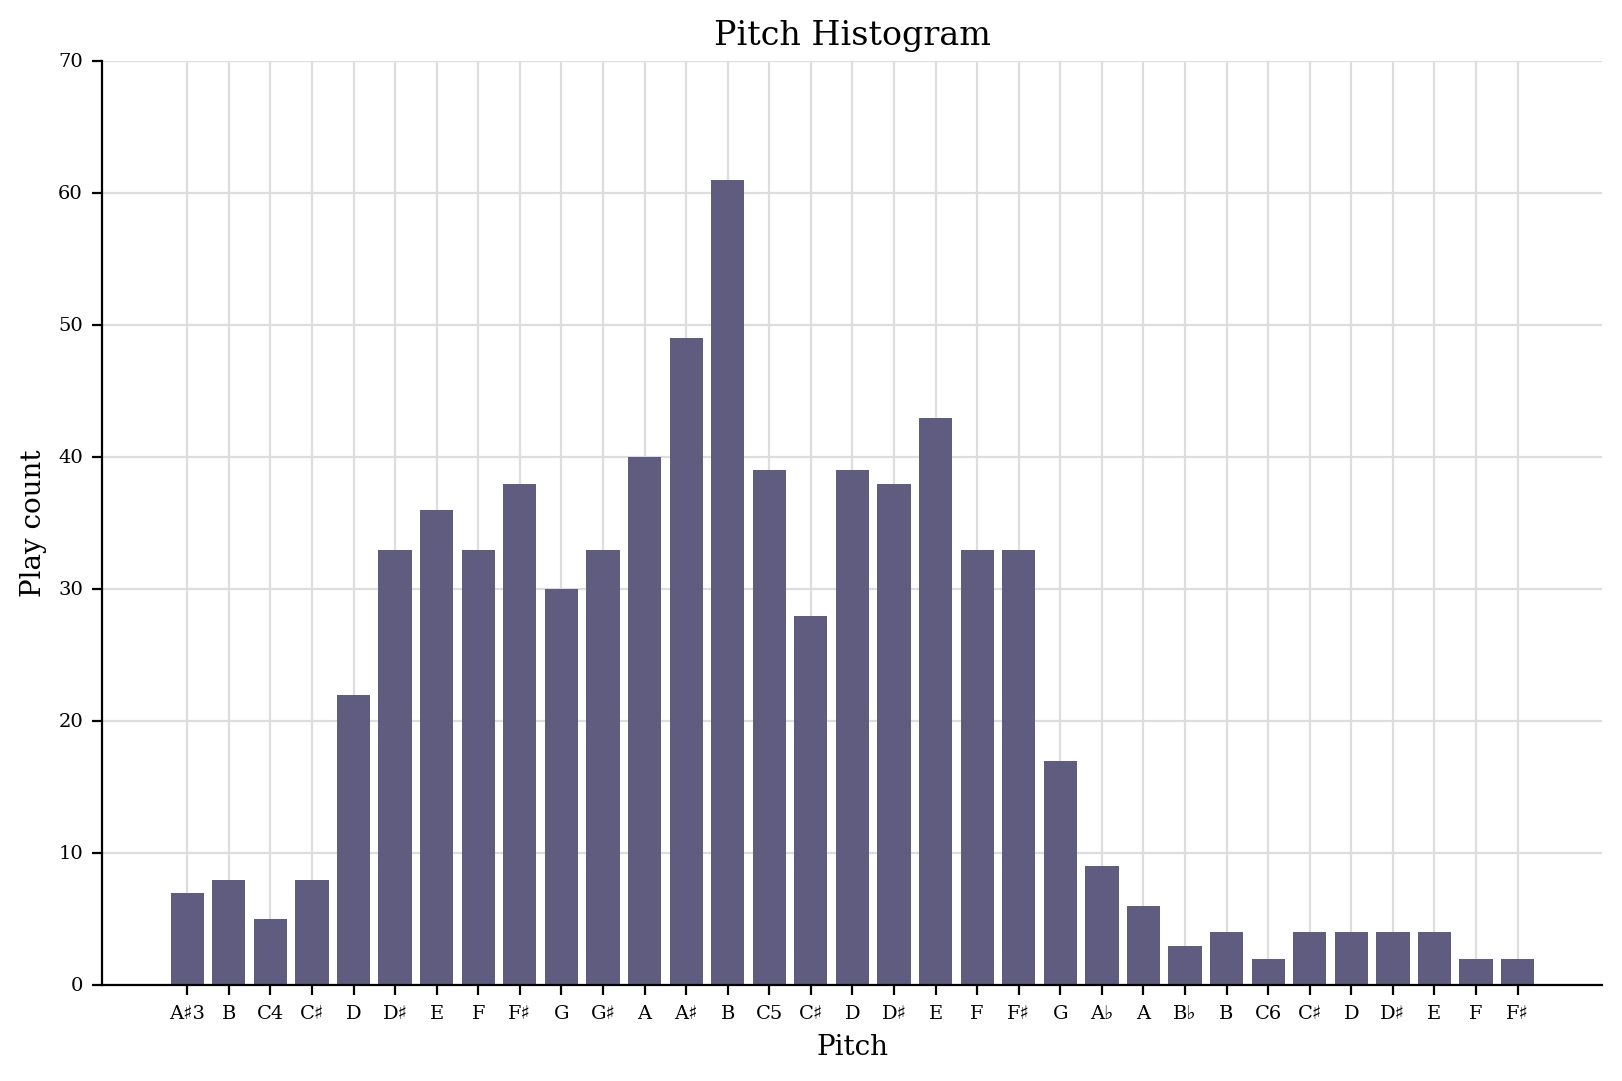

In [6]:
# Looks like we use every single note between the lowest note (A#3) and the highest (F#6)
# at least once. Ironically, we hit the "B" an awful lot!!!! Doesn't really mean anything 
# though, becasue this is a clarinet score, which means it is transposed
score.plot('histogram', 'pitch', xHideUnused=False,
          xLabel="Pitch", yLabel="Play count")

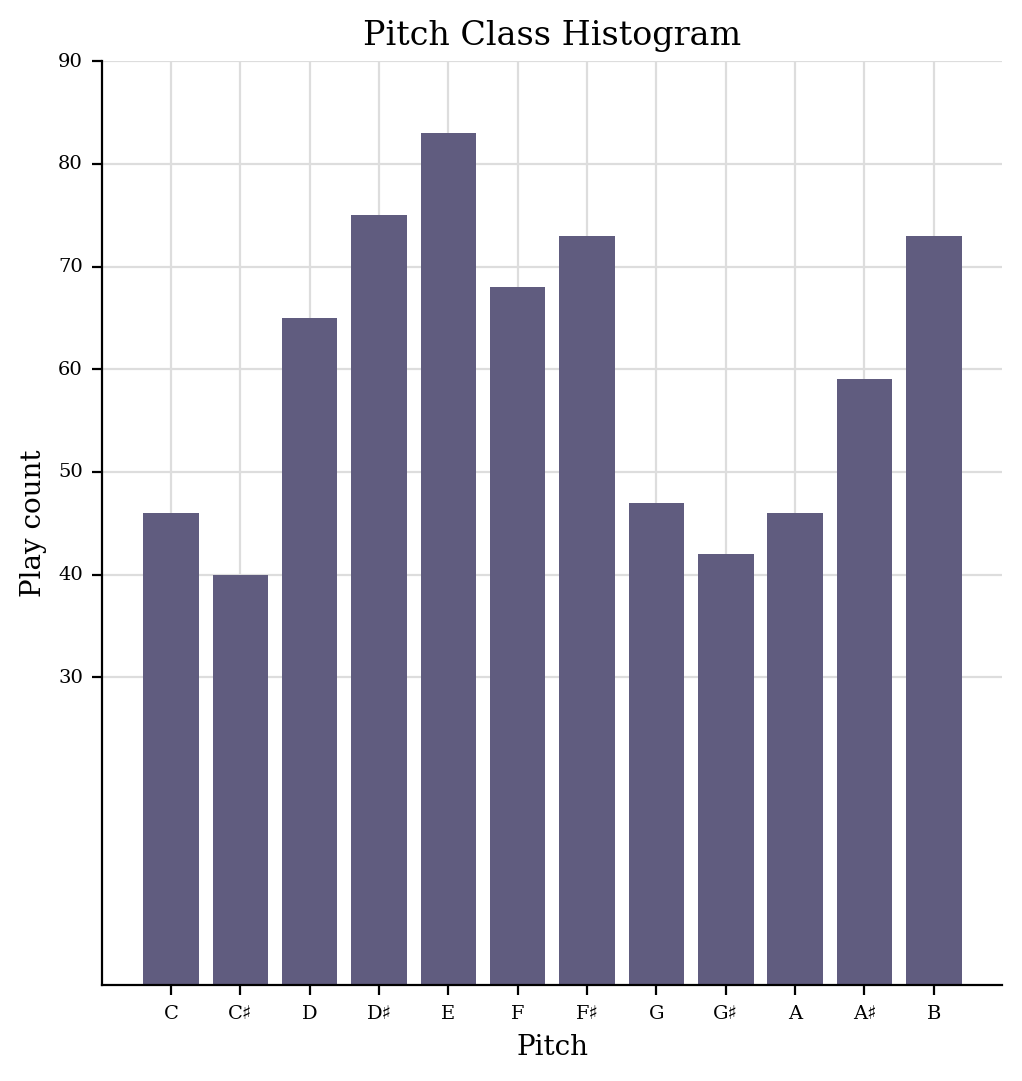

In [7]:
score.plot('histogram', 'pitchClass', xHideUnused=False,
          xLabel="Pitch", yLabel="Play count")

In [8]:
# What's our note count?
# From a previous notebook we have a function for that
def count_notes_played(input):
    total = 0
    for n in input.recurse().notes:
        if n.tie and n.tie.type != "start":
            continue
        if len(n.expressions) and type(n.expressions[0]) is expressions.Tremolo:
            if n.expressions[0]._numberOfMarks != 1:
                print("Unhandled: tremolo notation with >1 slash")
            total += 2
        else:
            total += 1
    return total
        
count_notes_played(score)

717

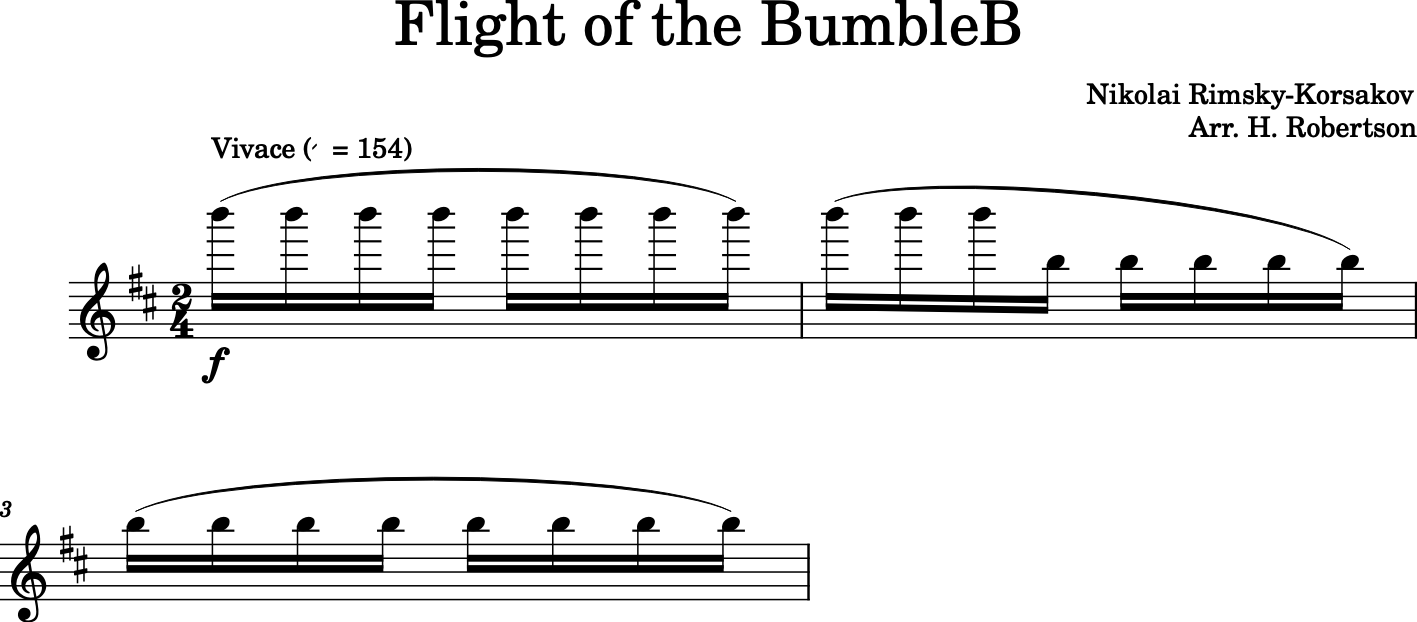

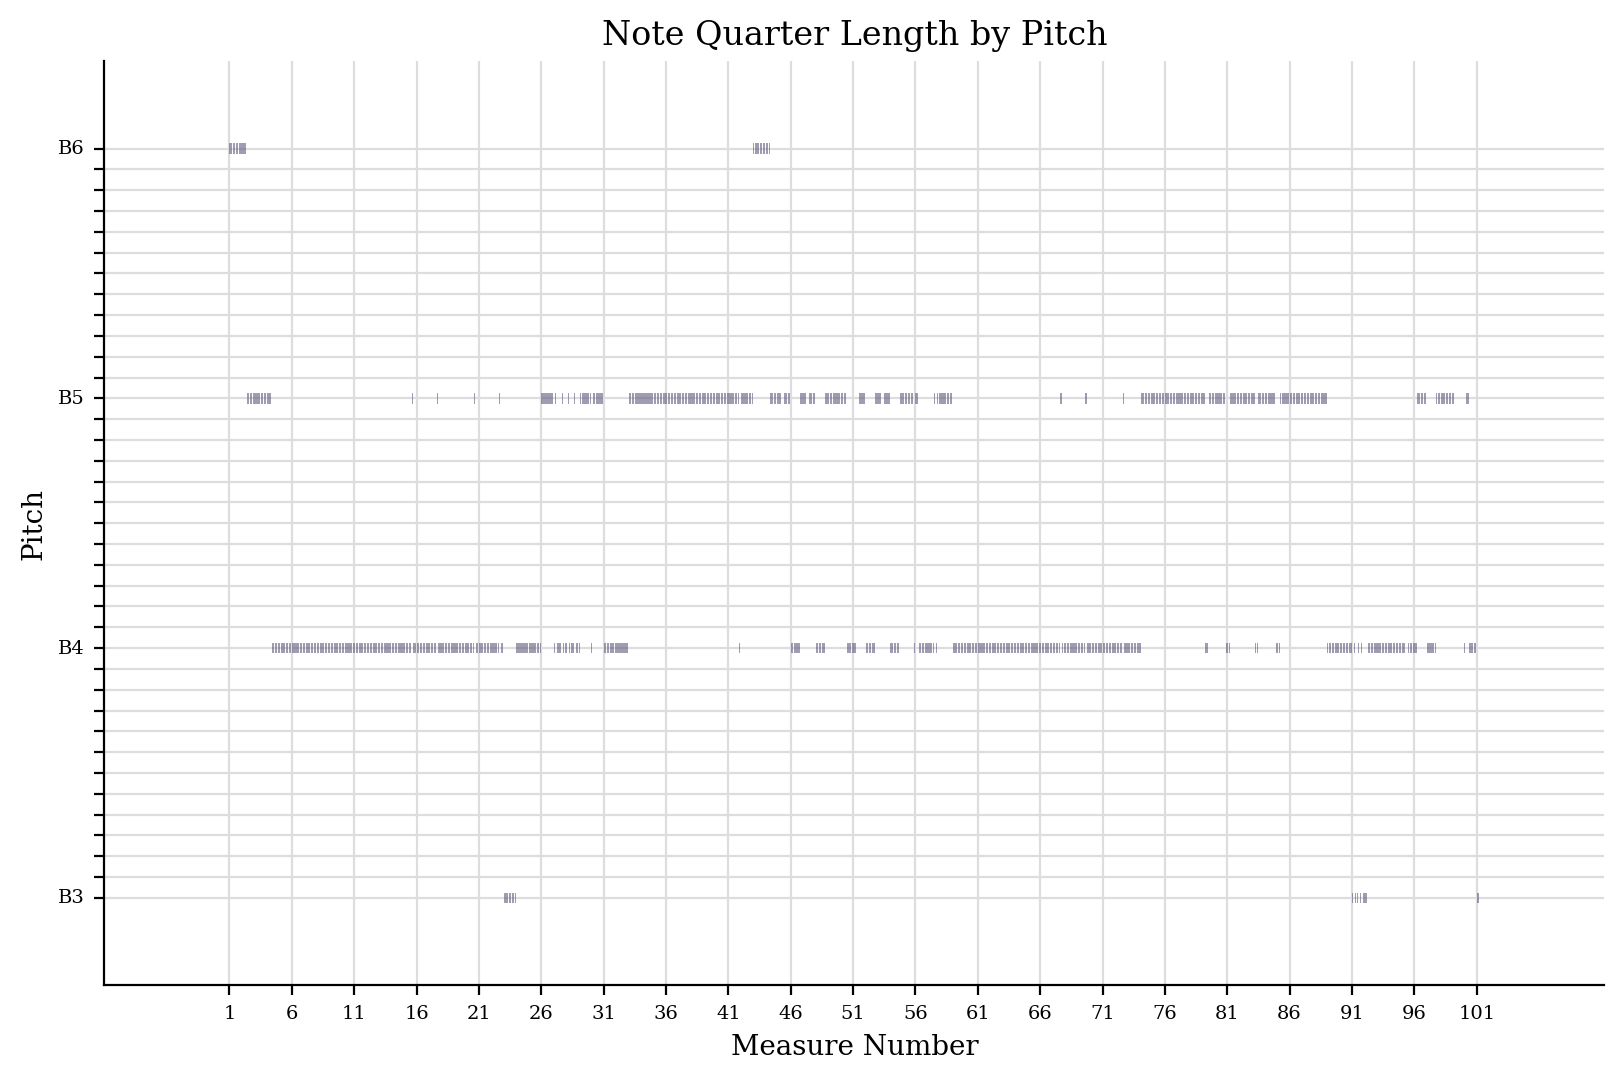

In [9]:
# What happens if we turn this into flight of the bumble B?
# Let's persist the octave of the original, though
score_b = copy.deepcopy(score)
score_b.metadata.composer = "Nikolai Rimsky-Korsakov\nArr. H. Robertson"
score_b.metadata.movementName = "Flight of the BumbleB"

for n in score_b.recurse().notes:
    n.pitch.name = ('B')

score_b.measures(1,3).show()
score_b.show('midi')
score_b.plot('pianoroll')

In [23]:
# We all know that the crow is a more direct traveler. 
# Let's assume that the bumblebee has traveled exactly 
# where it wanted to travel (i.e., preserve all pitches) and spent as long as it 
# intended at each place (preserve duration)
# but that it did not do it particularly directly (i.e., do not preserve order).
# Now the crow is teaching it how to hit those same destinations in a more direct way.

score_crow = copy.deepcopy(score)
score_crow.metadata.composer = "Nikolai Rimsky-Korsakov\nArr. H. Robertson"
score_crow.metadata.movementName = "Flight of the Bumblebee following Crow's navigation"

sorted_notes = sorted(score.recurse().notes)
for i in range(0,len(score_crow.recurse().notes)):
    score_crow.recurse().notes[i] = sorted_notes[i]

TypeError: 'RecursiveIterator' object does not support item assignment

In [ ]:

score_crow.measures(1,3).show()
score_crow.show('midi')
score_crow.plot('pianoroll')

In [21]:
for i in range(1,10):
    print(i)


1
2
3
4
5
6
7
8
9


In [15]:
score_crow.notes

<music21.stream.iterator.StreamIterator for Score:0x10ea7cbd0 @:0>